<a href="https://colab.research.google.com/github/Jay-PhDAI/PhDAI_732_GP1/blob/main/PhDAI732_GP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using snippets of code from https://github.com/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb
example.

In [39]:
import sys
assert sys.version_info >= (3, 7)

from packaging import version
import sklearn
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
from sklearn.preprocessing import MinMaxScaler

from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import requests
import matplotlib.pyplot as plt

Function to download and import the dataset from my Github.

In [40]:
def load_taxi_data(filename):
    # Define the target path for the final parquet file
    final_parquet_dir = Path("datasets/taxi")
    # The file name as found in the GitHub repository
    source_filename = filename
    final_parquet_path = final_parquet_dir / source_filename

    # Ensure the target directory exists
    final_parquet_dir.mkdir(parents=True, exist_ok=True)

    # If the final parquet file does not exist, proceed with download
    if not final_parquet_path.is_file():

        # Correct URL for raw GitHub content, assuming 'main' branch and correct path within repo
        url = f"https://raw.githubusercontent.com/Jay-PhDAI/PhDAI_732_GP1/main/{source_filename}"

        # Define a temporary path to download the file to first
        temp_download_path = final_parquet_dir / source_filename

        print(f"Downloading data from: {url} using requests library")
        response = requests.get(url, stream=True)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        with open(temp_download_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Downloaded to: {temp_download_path}")

    else:
        print(f"File already exists: {final_parquet_path}. Skipping download.")

    # Directly read the final parquet file
    return pd.read_parquet(final_parquet_path)

Datasets for NYC green taxicab tripdata now will be downloaded. We are going to use the first 5 months of 2026,(I am only using the first month for testing) and concatenate them into one dataframe.
Then we want to get some info about the dataset. Taking a peek at the dataset:

File already exists: datasets/taxi/green_tripdata_2026-01.parquet. Skipping download.
File already exists: datasets/taxi/green_tripdata_2026-02.parquet. Skipping download.
File already exists: datasets/taxi/green_tripdata_2026-03.parquet. Skipping download.
File already exists: datasets/taxi/green_tripdata_2026-04.parquet. Skipping download.
File already exists: datasets/taxi/green_tripdata_2026-05.parquet. Skipping download.
<class 'pandas.core.frame.DataFrame'>
Index: 211012 entries, 0 to 44920
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               211012 non-null  int32         
 1   lpep_pickup_datetime   211012 non-null  datetime64[us]
 2   lpep_dropoff_datetime  211012 non-null  datetime64[us]
 3   store_and_fwd_flag     181457 non-null  object        
 4   RatecodeID             181457 non-null  float64       
 5   PULocationID           211012 non-null  

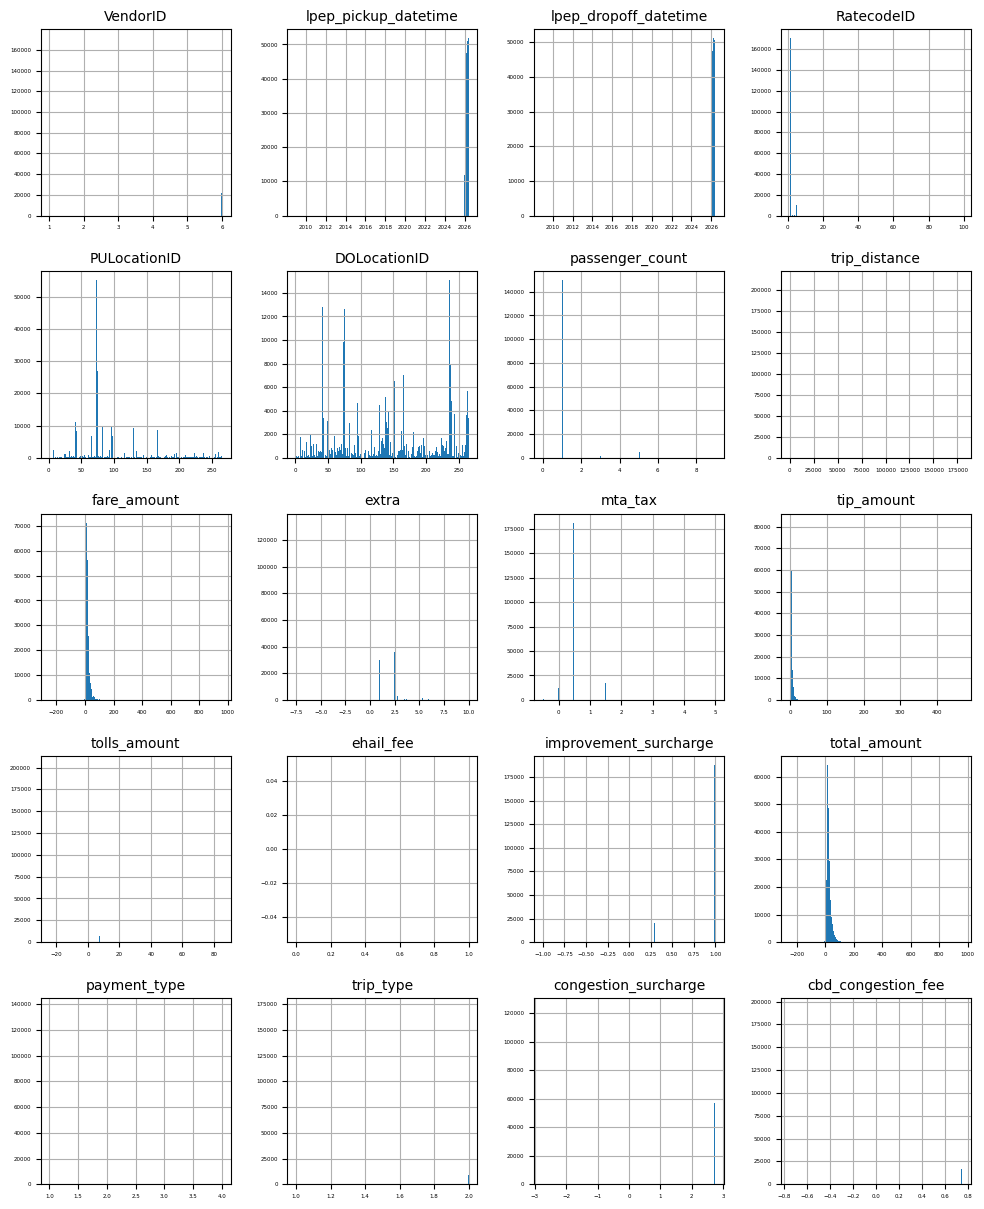

In [41]:
taxi1 = load_taxi_data("green_tripdata_2026-01.parquet")
taxi2 = load_taxi_data("green_tripdata_2026-02.parquet")
taxi3 = load_taxi_data("green_tripdata_2026-03.parquet")
taxi4 = load_taxi_data("green_tripdata_2026-04.parquet")
taxi5 = load_taxi_data("green_tripdata_2026-05.parquet")

taxi = pd.concat([taxi1, taxi2, taxi3, taxi4, taxi5])
# making an unadulterated copy of the concatenated dataframe
taxi_copy = taxi

taxi.info()
taxi.describe()
taxi.lpep_dropoff_datetime.info()
taxi

plt.rc('font', size=10)
plt.rc('axes', labelsize=10, titlesize=10)
plt.rc('legend', fontsize=10)
plt.rc('xtick', labelsize=4)
plt.rc('ytick', labelsize=4)

taxi.hist(bins=180, figsize=(12, 15))
plt.show()

We need some sort of problem to solve. I think it would be interesting to try to determine what time of day is the best for a driver to earn tips.

Maybe look at averages of tips per hour # of the day (00-23).

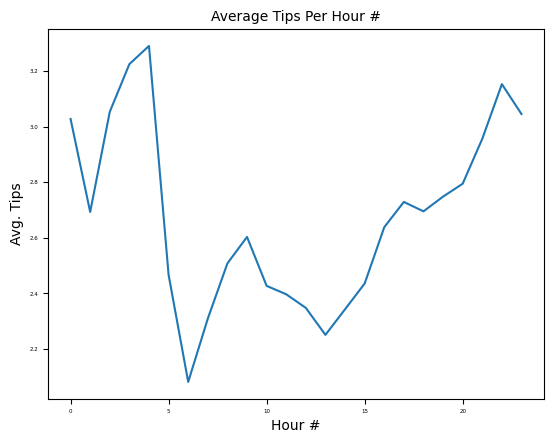

In [42]:
#test = taxi1

taxi['lpep_dropoff_datetime'] = pd.to_datetime(taxi['lpep_dropoff_datetime'])
taxi['hour'] = taxi['lpep_dropoff_datetime'].dt.hour

#print(test['hour'].value_counts())
#print(taxi.groupby('hour')['tip_amount'].mean())
#plt.plot(test['lpep_dropoff_datetime'].dt.hour, test.tip_amount)

plt.plot(taxi.groupby('hour')['tip_amount'].mean())
plt.xlabel('Hour #')
plt.ylabel('Avg. Tips')
plt.title('Average Tips Per Hour #')
plt.show()

The tips are based off of credit card tips only. Cash tips are not taken into consideration and are marked zero. I think we should preprocess the data and remove the row entries with 0 as the tip. We would be looking at the average credit card tips per hour.